What we are looking for,
We aim to understand why and where the model expresses uncertainty or refusal when faced with a fictional or unanswerable question.
Specifically, we want to determine if this behavior arises from specific parts of the model’s internal computations like
layers or attention heads—and whether it is caused by distinct circuits or superposition of information.

Experiments to test this,  

**1. Layerwise Residual Difference:**
- Measures how much the model’s internal residual representations differ layer-by-layer between a real factual question and a fictional/uncertain question,
- showing where uncertainty starts to emerge in the network.

**2. Headwise Divergence Heatmap:**
- Analyzes which attention heads in each layer contribute most to the difference in model processing between the real and fictional questions,
- helping identify specific heads responsible for uncertainty or refusal behavior.

**3. Ablation Curve on Top Heads:**
- Gradually “turns off” (ablates) the most divergent heads to see how this affects the model’s probability assigned to uncertainty-related tokens,
- revealing if those heads drive the model’s uncertainty or refusal responses.


In [1]:
! pip install transformer_lens

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 192.0/192.0 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.7/739.7 kB 34.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 55.2 MB/s eta 0:00:00
  Created wheel for transformers-stream-generator: filename=transformers_stream_generator-0.0.5-py3-none-any.whl size=12426 sha256=8c0abc6e8ca3ef7433d37aa7ca385af306a07569af2bcd1b41ba4800e046817c
  Stored in directory: /root/.cache/pip/wheels/a8/58/d2/014cb67c3cc6def738c1b1635dbf4e3dab6fb63aba7070dce0
Successfully built transformers-stream-generator
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
  Attempting uninstall: beartype
    Found existing installat

In [9]:
import os
import torch
import matplotlib.pyplot as plt
from transformer_lens import HookedTransformer
from collections import defaultdict

In [10]:
class UncertaintyExperimentBase:
    """Base class for uncertainty circuit experiments."""

    def __init__(self, model_name, prompt_real, prompt_fake, results_dir="./results"):
        self.model_name = model_name
        self.prompt_real = prompt_real
        self.prompt_fake = prompt_fake
        self.results_dir = results_dir

        # Setup device and dtype
        self.device = "cuda" if torch.cuda.is_available() else "cpu"
        self.dtype = torch.float16 if torch.cuda.is_available() else torch.float32

        # Create results directory
        os.makedirs(self.results_dir, exist_ok=True)
        self.model_dir = os.path.join(self.results_dir, model_name.replace("/", "_"))
        os.makedirs(self.model_dir, exist_ok=True)

        # Load model
        print(f"Loading {model_name}...")
        self.model = HookedTransformer.from_pretrained_no_processing(
            model_name, device=self.device, dtype=self.dtype
        )

        # Get uncertainty tokens
        self.uncertainty_tokens = self._get_uncertainty_tokens()
        print(f"  Uncertainty tokens: {len(self.uncertainty_tokens)} found")

    def _get_uncertainty_tokens(self):
        """Get uncertainty tokens for the model's tokenizer."""
        uncertainty_words = [
            "unknown", "unsure", "don", "'t", "know", "can't", "unable", "impossible",
            "doesn't", "exist", "fictional", "imaginary", "no", "such", "thing",
            "hypothetical", "made", "up", "never", "happened"
        ]
        token_ids = []
        for w in uncertainty_words:
            try:
                toks = self.model.to_tokens(" " + w, prepend_bos=False)[0]
                token_ids.extend(toks.tolist())
            except Exception:
                pass
        return sorted(list(set(token_ids)))

    def _run_model_with_cache(self, prompt):
        """Run model and return logits + cache."""
        logits, cache = self.model.run_with_cache(prompt)
        return logits, cache

    def cleanup(self):
        """Free memory."""
        del self.model
        torch.cuda.empty_cache() if torch.cuda.is_available() else None
        print(f"Cleaned up {self.model_name}")

## Layer wise Residual differnece

In [17]:
class LayerwiseResidualDifference(UncertaintyExperimentBase):
    """Measures layerwise residual stream divergence between real and fake prompts."""

    def __init__(self, model_name, prompt_real, prompt_fake, results_dir="./results_layerwise"):
        super().__init__(model_name, prompt_real, prompt_fake, results_dir)

    def _compute_residual_diff(self, cache_real, cache_fake):
        """Compute residual norm difference per layer."""
        diffs = []
        for layer in range(self.model.cfg.n_layers):
            real_resid = cache_real[f"blocks.{layer}.hook_resid_post"][0]
            fake_resid = cache_fake[f"blocks.{layer}.hook_resid_post"][0]

            # Handle different sequence lengths
            min_len = min(real_resid.shape[0], fake_resid.shape[0])

            diff = torch.norm(
                real_resid[:min_len, :] - fake_resid[:min_len, :]
            ).item()
            diffs.append(diff)

        return diffs

    def _plot_results(self, diffs, filename):
        """Plot layerwise differences."""
        plt.figure(figsize=(10, 6))
        plt.plot(range(len(diffs)), diffs, marker='o', linewidth=2, markersize=8)
        plt.title(f"Layerwise Residual Difference: {self.model_name}", fontsize=14, fontweight='bold')
        plt.xlabel("Layer", fontsize=12)
        plt.ylabel("Residual Norm Difference", fontsize=12)
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(filename, dpi=150)
        plt.show()
        plt.close()
        print(f"  Saved: {filename}")

    def run(self):
        """Execute the experiment."""
        print(f"\n{'='*60}")
        print(f"Experiment: Layerwise Residual Difference")
        print(f"Model: {self.model_name}")
        print(f"{'='*60}")

        print("Running model on real prompt...")
        logits_real, cache_real = self._run_model_with_cache(self.prompt_real)

        print("Running model on fake prompt...")
        logits_fake, cache_fake = self._run_model_with_cache(self.prompt_fake)

        print("Computing layerwise residual differences...")
        layer_diffs = self._compute_residual_diff(cache_real, cache_fake)

        # Plot
        output_path = os.path.join(self.model_dir, "layerwise_residual_diff.png")
        self._plot_results(layer_diffs, output_path)

        print(f"Results saved to {self.model_dir}")
        return layer_diffs

## HeadWise Divergence

In [16]:
class HeadwiseDivergence(UncertaintyExperimentBase):
    """Analyzes which attention heads contribute most to divergence between real and fake prompts."""

    def __init__(self, model_name, prompt_real, prompt_fake, results_dir="./results_headwise"):
        super().__init__(model_name, prompt_real, prompt_fake, results_dir)

    def _compute_headwise_divergence(self, cache_real, cache_fake):
        """Compute divergence per attention head."""
        n_layers = self.model.cfg.n_layers
        n_heads = self.model.cfg.n_heads
        head_diffs = torch.zeros(n_layers, n_heads)

        for layer in range(n_layers):
            real_heads = cache_real[f"blocks.{layer}.attn.hook_z"][0]
            fake_heads = cache_fake[f"blocks.{layer}.attn.hook_z"][0]

            # Handle different sequence lengths
            min_len = min(real_heads.shape[0], fake_heads.shape[0])

            for head in range(n_heads):
                diff = torch.norm(
                    real_heads[:min_len, head, :] - fake_heads[:min_len, head, :]
                ).item()
                head_diffs[layer, head] = diff

        return head_diffs

    def _plot_heatmap(self, head_diffs, filename):
        """Plot headwise divergence as heatmap."""
        plt.figure(figsize=(14, 8))
        im = plt.imshow(head_diffs.numpy(), aspect='auto', cmap='viridis', interpolation='nearest')
        plt.colorbar(im, label="Head Divergence")
        plt.xlabel("Head Index", fontsize=12)
        plt.ylabel("Layer", fontsize=12)
        plt.title(f"Headwise Divergence Heatmap: {self.model_name}", fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.savefig(filename, dpi=150)
        plt.show()
        plt.close()
        print(f"  Saved: {filename}")

    def _print_top_heads(self, head_diffs, top_k=10):
        """Print top-k most divergent heads."""
        flat_heads = sorted(
            [((l, h), head_diffs[l, h].item()) for l in range(self.model.cfg.n_layers)
             for h in range(self.model.cfg.n_heads)],
            key=lambda x: x[1], reverse=True
        )

        print(f"\nTop {top_k} Most Divergent Heads:")
        print(f"{'Rank':<6} {'Head':<10} {'Divergence':<15}")
        print(f"{'-'*35}")
        for i, ((layer, head), div) in enumerate(flat_heads[:top_k]):
            print(f"{i+1:<6} L{layer}H{head:<8} {div:<15.4f}")

        return flat_heads

    def run(self):
        """Execute the experiment."""
        print(f"\n{'='*60}")
        print(f"Experiment: Headwise Divergence")
        print(f"Model: {self.model_name}")
        print(f"{'='*60}")

        print("Running model on real prompt...")
        logits_real, cache_real = self._run_model_with_cache(self.prompt_real)

        print("Running model on fake prompt...")
        logits_fake, cache_fake = self._run_model_with_cache(self.prompt_fake)

        print("Computing headwise divergence...")
        head_diffs = self._compute_headwise_divergence(cache_real, cache_fake)

        # Plot heatmap
        output_path = os.path.join(self.model_dir, "headwise_divergence_heatmap.png")
        self._plot_heatmap(head_diffs, output_path)

        # Print top heads
        self._print_top_heads(head_diffs, top_k=15)

        print(f"Results saved to {self.model_dir}")
        return head_diffs

## Ablation

In [15]:
class AblationCurve(UncertaintyExperimentBase):
    """Tests effect of ablating top divergent heads on uncertainty mass."""

    def __init__(self, model_name, prompt_real, prompt_fake, results_dir="./results_ablation"):
        super().__init__(model_name, prompt_real, prompt_fake, results_dir)

    def _ablate_heads(self, heads_to_ablate, prompt):
        """Ablate specific heads and return logits."""
        heads_by_layer = defaultdict(list)
        for (layer, head) in heads_to_ablate:
            heads_by_layer[layer].append(head)

        hooks = []
        for layer, heads in heads_by_layer.items():
            def make_hook(heads_to_zero):
                def hook_fn(value, hook):
                    value = value.clone()
                    for h in heads_to_zero:
                        value[:, :, h, :] = 0
                    return value
                return hook_fn

            hooks.append((f"blocks.{layer}.attn.hook_z", make_hook(heads)))

        logits = self.model.run_with_hooks(prompt, fwd_hooks=hooks)
        return logits[0, -1]

    def _uncertainty_mass(self, logits):
        """Compute probability mass on uncertainty tokens."""
        probs = torch.softmax(logits, dim=-1)
        return probs[self.uncertainty_tokens].sum().item()

    def _compute_head_diffs(self, cache_real, cache_fake):
        """Compute headwise divergence for ranking."""
        n_layers = self.model.cfg.n_layers
        n_heads = self.model.cfg.n_heads
        head_diffs = torch.zeros(n_layers, n_heads)

        for layer in range(n_layers):
            real_heads = cache_real[f"blocks.{layer}.attn.hook_z"][0]
            fake_heads = cache_fake[f"blocks.{layer}.attn.hook_z"][0]

            min_len = min(real_heads.shape[0], fake_heads.shape[0])

            for head in range(n_heads):
                diff = torch.norm(
                    real_heads[:min_len, head, :] - fake_heads[:min_len, head, :]
                ).item()
                head_diffs[layer, head] = diff

        return head_diffs

    def _plot_ablation_curve(self, steps, masses, top_k, filename):
        """Plot ablation curve."""
        plt.figure(figsize=(12, 6))
        plt.plot(steps, masses, marker='o', linewidth=2, markersize=6, color='steelblue')
        plt.xlabel(f"Number of Top {top_k} Heads Ablated", fontsize=12)
        plt.ylabel("Uncertainty Token Probability Mass", fontsize=12)
        plt.title(f"Ablation Curve: Effect on Uncertainty - {self.model_name}", fontsize=14, fontweight='bold')
        plt.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.savefig(filename, dpi=150)
        plt.show()
        plt.close()
        print(f"  Saved: {filename}")

    def run(self, top_k=50, prompt_to_ablate="fake"):
        """Execute the experiment.

        Args:
            top_k (int): Number of most divergent heads to consider
            prompt_to_ablate (str): Which prompt to run ablation on ('real' or 'fake')
        """
        print(f"\n{'='*60}")
        print(f"Experiment: Ablation Curve")
        print(f"Model: {self.model_name}")
        print(f"Top-K heads: {top_k}")
        print(f"Ablating on: {prompt_to_ablate} prompt")
        print(f"{'='*60}")

        print("Running model on real prompt...")
        logits_real, cache_real = self._run_model_with_cache(self.prompt_real)

        print("Running model on fake prompt...")
        logits_fake, cache_fake = self._run_model_with_cache(self.prompt_fake)

        print("Computing headwise divergence for ranking...")
        head_diffs = self._compute_head_diffs(cache_real, cache_fake)

        # Rank heads by divergence
        flat_heads = sorted(
            [((l, h), head_diffs[l, h].item()) for l in range(self.model.cfg.n_layers)
             for h in range(self.model.cfg.n_heads)],
            key=lambda x: x[1], reverse=True
        )
        top_heads = [x[0] for x in flat_heads[:top_k]]

        print(f"Top {top_k} heads selected for ablation")

        # Select which prompt to ablate
        prompt_to_test = self.prompt_fake if prompt_to_ablate == "fake" else self.prompt_real

        # Run ablation curve
        print(f"Running ablation on {prompt_to_ablate} prompt...")
        masses = []
        steps = list(range(0, len(top_heads), 1))

        for k in steps:
            heads_to_ablate = top_heads[:k]
            logits = self._ablate_heads(heads_to_ablate, prompt_to_test)
            mass = self._uncertainty_mass(logits)
            masses.append(mass)

            if k % 10 == 0:
                print(f"  {k}/{len(top_heads)} heads ablated, uncertainty mass: {mass:.6f}")

        # Plot
        output_path = os.path.join(self.model_dir, f"ablation_curve_{prompt_to_ablate}.png")
        self._plot_ablation_curve(steps, masses, top_k, output_path)

        print(f"Results saved to {self.model_dir}")
        return steps, masses

## Running experiments



######################################################################
# RUNNING ALL EXPERIMENTS FOR: meta-llama/Llama-3.2-1B
######################################################################


[1/3] Running Layerwise Residual Difference...
Loading meta-llama/Llama-3.2-1B...


config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Layerwise Residual Difference
Model: meta-llama/Llama-3.2-1B
Running model on real prompt...
Running model on fake prompt...
Computing layerwise residual differences...


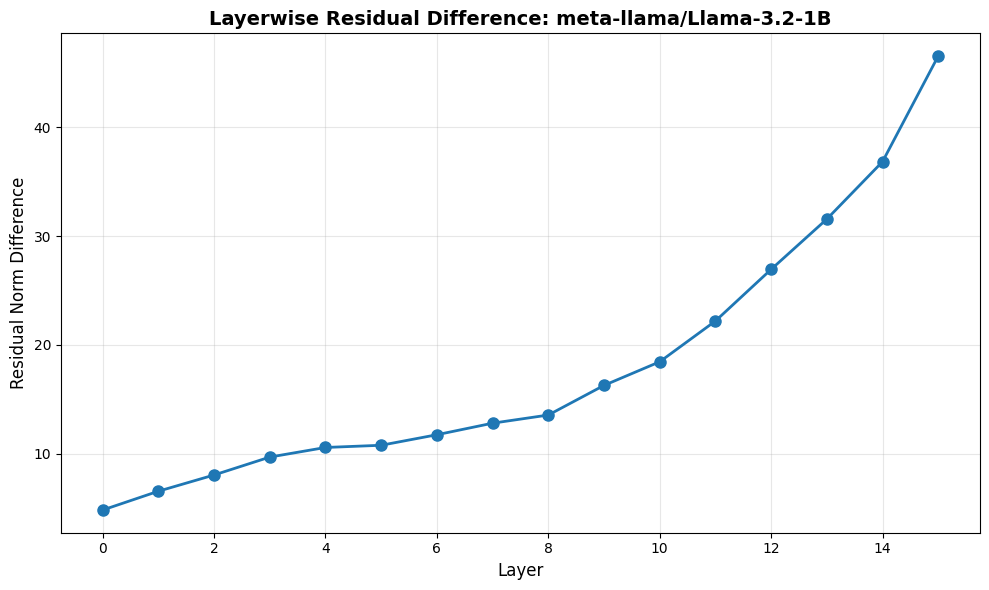

  Saved: ./results_layerwise/meta-llama_Llama-3.2-1B/layerwise_residual_diff.png
Results saved to ./results_layerwise/meta-llama_Llama-3.2-1B
Cleaned up meta-llama/Llama-3.2-1B

[2/3] Running Headwise Divergence...
Loading meta-llama/Llama-3.2-1B...
Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Headwise Divergence
Model: meta-llama/Llama-3.2-1B
Running model on real prompt...
Running model on fake prompt...
Computing headwise divergence...


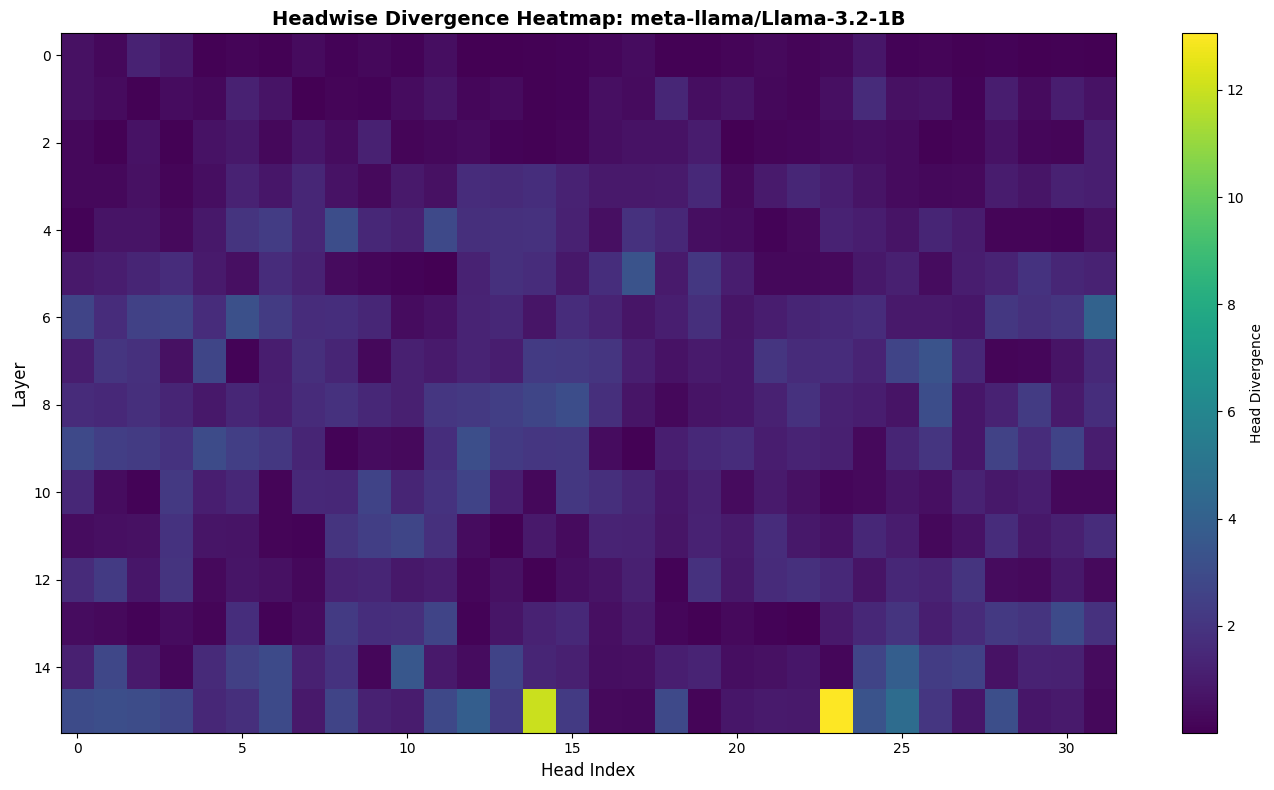

  Saved: ./results_headwise/meta-llama_Llama-3.2-1B/headwise_divergence_heatmap.png

Top 15 Most Divergent Heads:
Rank   Head       Divergence     
-----------------------------------
1      L15H23       13.0547        
2      L15H14       11.9922        
3      L15H25       4.6445         
4      L6H31       4.0977         
5      L14H25       3.9180         
6      L15H12       3.8867         
7      L14H10       3.5527         
8      L7H26       3.3496         
9      L5H17       3.3438         
10     L15H24       3.3281         
11     L6H5        3.1973         
12     L15H28       3.1582         
13     L9H12       3.1348         
14     L15H1        3.1230         
15     L8H15       3.1152         
Results saved to ./results_headwise/meta-llama_Llama-3.2-1B
Cleaned up meta-llama/Llama-3.2-1B

[3/3] Running Ablation Curve...
Loading meta-llama/Llama-3.2-1B...
Loaded pretrained model meta-llama/Llama-3.2-1B into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Abla

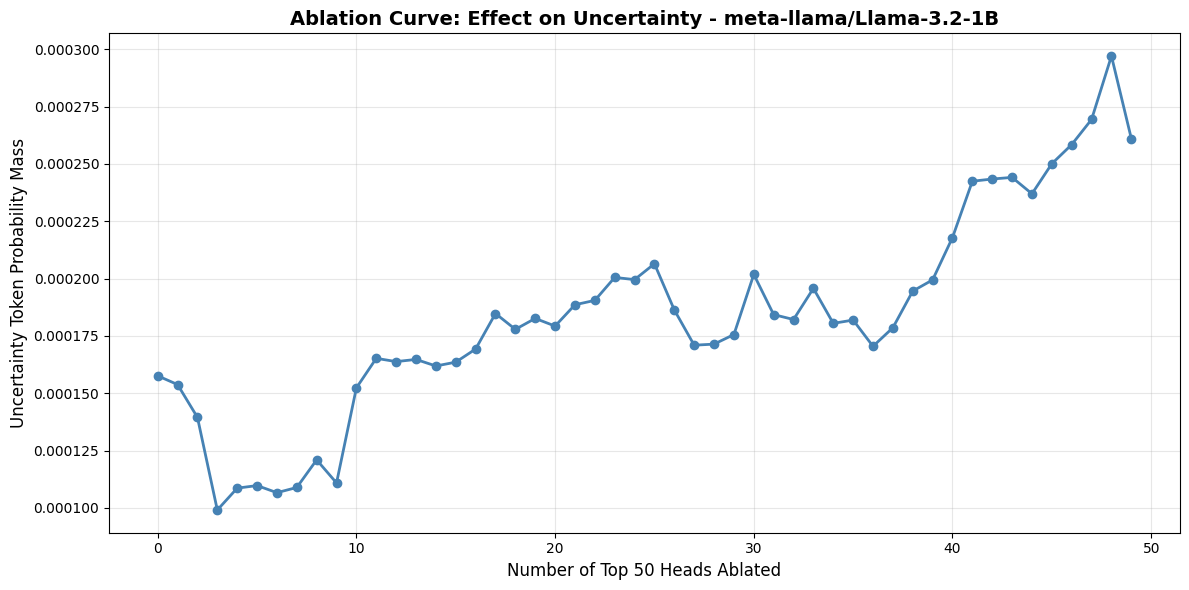

  Saved: ./results_ablation/meta-llama_Llama-3.2-1B/ablation_curve_fake.png
Results saved to ./results_ablation/meta-llama_Llama-3.2-1B
Cleaned up meta-llama/Llama-3.2-1B


All experiments completed for meta-llama/Llama-3.2-1B!



In [19]:

MODEL_NAMES = ["meta-llama/Llama-3.2-1B"]

prompt_real = "What is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "What is the freezing point of water on Planet Xylon, where gravity is twice that of Earth?"

for model_name in MODEL_NAMES:
    try:
        print(f"\n\n{'#'*70}")
        print(f"# RUNNING ALL EXPERIMENTS FOR: {model_name}")
        print(f"{'#'*70}\n")

        # Experiment 1: Layerwise Residual Difference
        print("\n[1/3] Running Layerwise Residual Difference...")
        exp1 = LayerwiseResidualDifference(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_layerwise"
        )
        exp1.run()
        exp1.cleanup()

        # Experiment 2: Headwise Divergence
        print("\n[2/3] Running Headwise Divergence...")
        exp2 = HeadwiseDivergence(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_headwise"
        )
        exp2.run()
        exp2.cleanup()

        # Experiment 3: Ablation Curve
        print("\n[3/3] Running Ablation Curve...")
        exp3 = AblationCurve(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_ablation"
        )
        exp3.run(top_k=50, prompt_to_ablate="fake")
        exp3.cleanup()

        print(f"\n\n{'='*70}")
        print(f"All experiments completed for {model_name}!")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"Error with {model_name}: {e}")
        import traceback
        traceback.print_exc()
        continue



######################################################################
# RUNNING ALL EXPERIMENTS FOR: meta-llama/Llama-3.2-1B-Instruct
######################################################################


[1/3] Running Layerwise Residual Difference...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Layerwise Residual Difference
Model: meta-llama/Llama-3.2-1B-Instruct
Running model on real prompt...
Running model on fake prompt...
Computing layerwise residual differences...


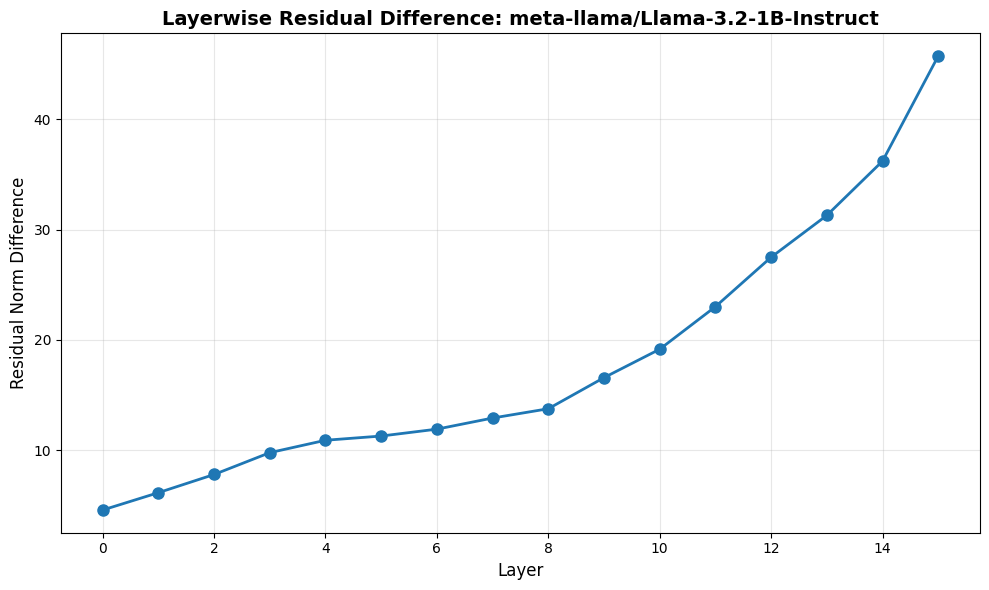

  Saved: ./results_layerwise/meta-llama_Llama-3.2-1B-Instruct/layerwise_residual_diff.png
Results saved to ./results_layerwise/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct

[2/3] Running Headwise Divergence...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Headwise Divergence
Model: meta-llama/Llama-3.2-1B-Instruct
Running model on real prompt...
Running model on fake prompt...
Computing headwise divergence...


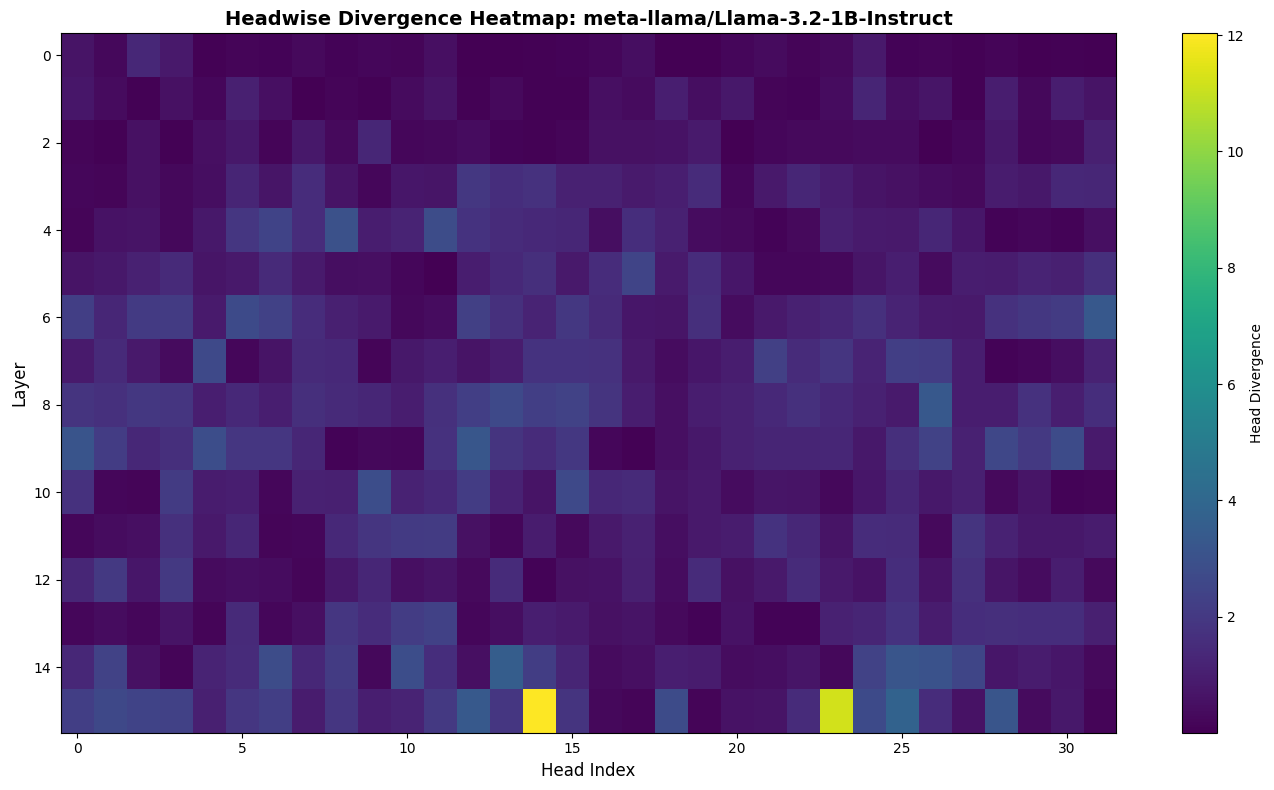

  Saved: ./results_headwise/meta-llama_Llama-3.2-1B-Instruct/headwise_divergence_heatmap.png

Top 15 Most Divergent Heads:
Rank   Head       Divergence     
-----------------------------------
1      L15H14       12.0312        
2      L15H23       11.2266        
3      L15H25       3.7930         
4      L14H13       3.5508         
5      L15H12       3.3574         
6      L6H31       3.3242         
7      L8H26       3.3066         
8      L9H12       3.2070         
9      L15H28       3.1680         
10     L14H25       3.1543         
11     L9H0        3.1211         
12     L14H26       3.0137         
13     L4H8        2.9980         
14     L14H10       2.8594         
15     L9H4        2.8574         
Results saved to ./results_headwise/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct

[3/3] Running Ablation Curve...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  U

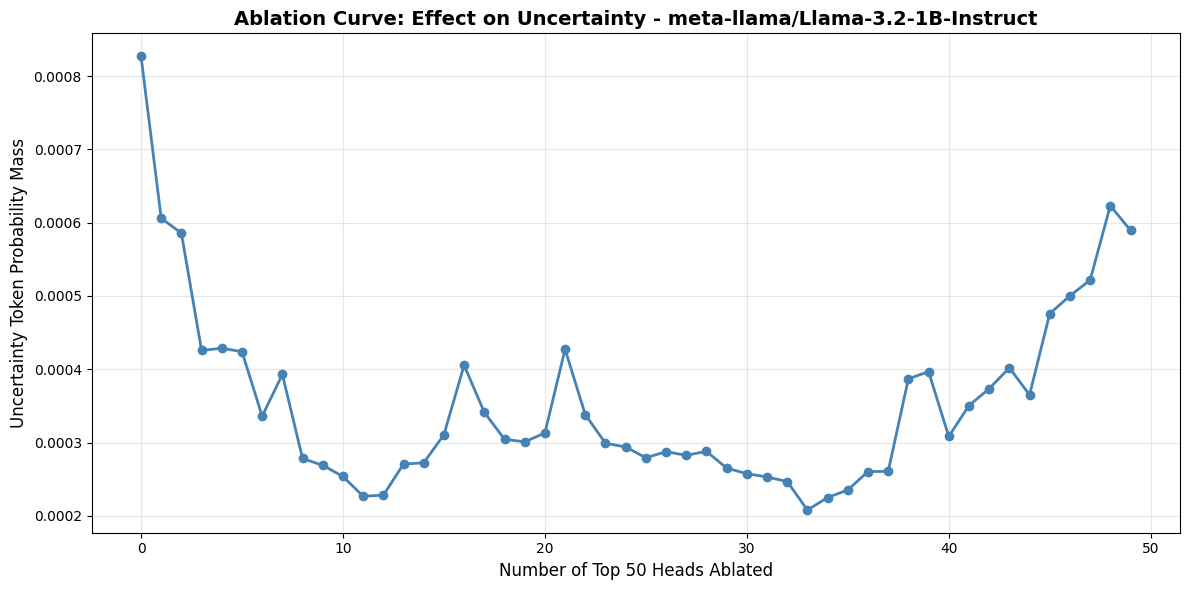

  Saved: ./results_ablation/meta-llama_Llama-3.2-1B-Instruct/ablation_curve_fake.png
Results saved to ./results_ablation/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct


All experiments completed for meta-llama/Llama-3.2-1B-Instruct!



In [18]:

MODEL_NAMES = ["meta-llama/Llama-3.2-1B-Instruct"]

prompt_real = "What is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "What is the freezing point of water on Planet Xylon, where gravity is twice that of Earth?"

for model_name in MODEL_NAMES:
    try:
        print(f"\n\n{'#'*70}")
        print(f"# RUNNING ALL EXPERIMENTS FOR: {model_name}")
        print(f"{'#'*70}\n")

        # Experiment 1: Layerwise Residual Difference
        print("\n[1/3] Running Layerwise Residual Difference...")
        exp1 = LayerwiseResidualDifference(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_layerwise"
        )
        exp1.run()
        exp1.cleanup()

        # Experiment 2: Headwise Divergence
        print("\n[2/3] Running Headwise Divergence...")
        exp2 = HeadwiseDivergence(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_headwise"
        )
        exp2.run()
        exp2.cleanup()

        # Experiment 3: Ablation Curve
        print("\n[3/3] Running Ablation Curve...")
        exp3 = AblationCurve(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_ablation"
        )
        exp3.run(top_k=50, prompt_to_ablate="fake")
        exp3.cleanup()

        print(f"\n\n{'='*70}")
        print(f"All experiments completed for {model_name}!")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"Error with {model_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

### Changing prompt sequence



######################################################################
# RUNNING ALL EXPERIMENTS FOR: meta-llama/Llama-3.2-1B-Instruct
######################################################################


[1/3] Running Layerwise Residual Difference...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Layerwise Residual Difference
Model: meta-llama/Llama-3.2-1B-Instruct
Running model on real prompt...
Running model on fake prompt...
Computing layerwise residual differences...


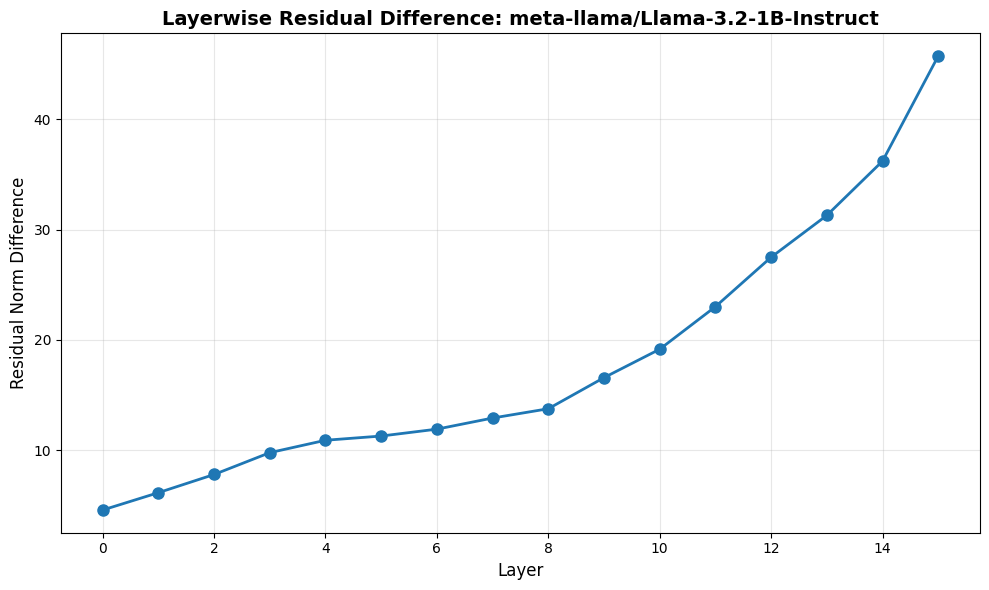

  Saved: ./results_layerwise/meta-llama_Llama-3.2-1B-Instruct/layerwise_residual_diff.png
Results saved to ./results_layerwise/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct

[2/3] Running Headwise Divergence...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Headwise Divergence
Model: meta-llama/Llama-3.2-1B-Instruct
Running model on real prompt...
Running model on fake prompt...
Computing headwise divergence...


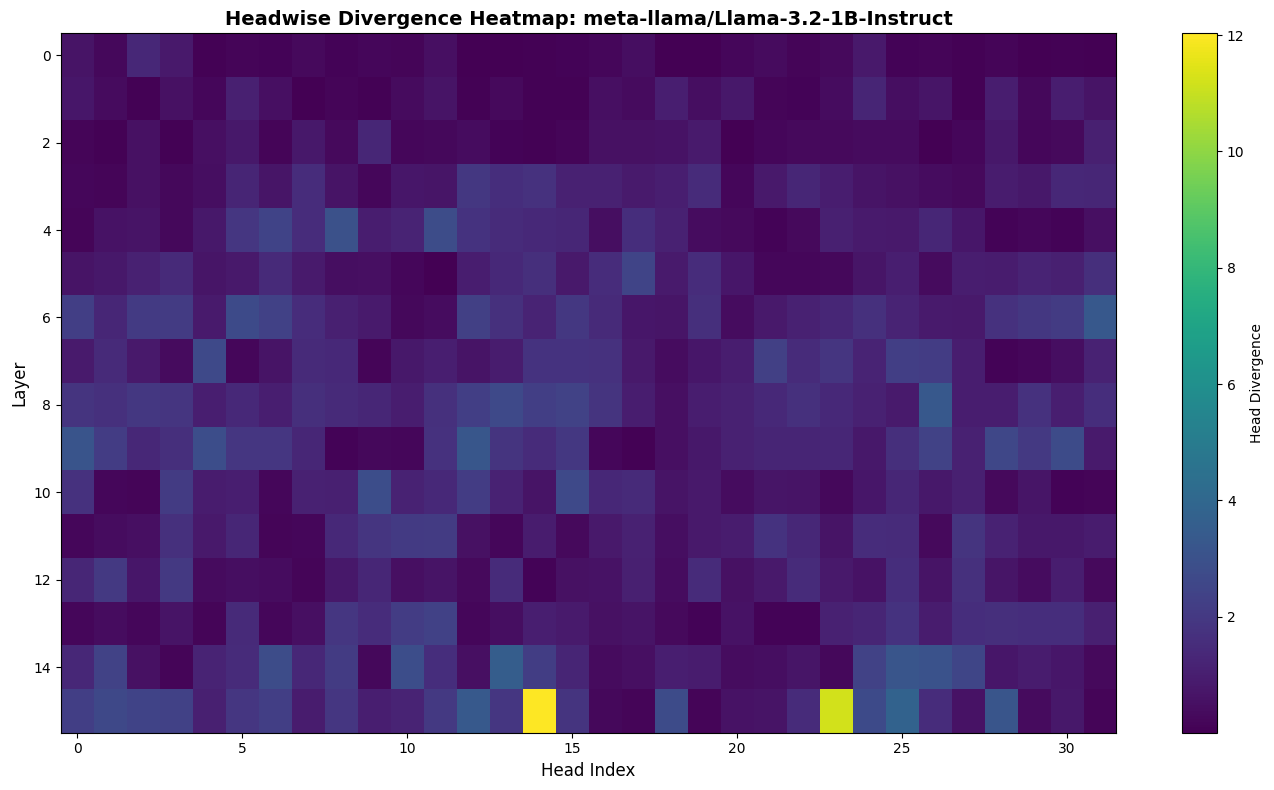

  Saved: ./results_headwise/meta-llama_Llama-3.2-1B-Instruct/headwise_divergence_heatmap.png

Top 15 Most Divergent Heads:
Rank   Head       Divergence     
-----------------------------------
1      L15H14       12.0312        
2      L15H23       11.2266        
3      L15H25       3.7930         
4      L14H13       3.5508         
5      L15H12       3.3574         
6      L6H31       3.3242         
7      L8H26       3.3066         
8      L9H12       3.2070         
9      L15H28       3.1680         
10     L14H25       3.1543         
11     L9H0        3.1211         
12     L14H26       3.0137         
13     L4H8        2.9980         
14     L14H10       2.8594         
15     L9H4        2.8574         
Results saved to ./results_headwise/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct


All experiments completed for meta-llama/Llama-3.2-1B-Instruct!



In [20]:

MODEL_NAMES = ["meta-llama/Llama-3.2-1B-Instruct"]

prompt_real = "What is the freezing point of water at standard atmospheric pressure?"
prompt_fake = "What is the freezing point of water on Planet Xylon, where gravity is twice that of Earth?"

for model_name in MODEL_NAMES:
    try:
        print(f"\n\n{'#'*70}")
        print(f"# RUNNING ALL EXPERIMENTS FOR: {model_name}")
        print(f"{'#'*70}\n")

        # Experiment 1: Layerwise Residual Difference
        print("\n[1/3] Running Layerwise Residual Difference...")
        exp1 = LayerwiseResidualDifference(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_layerwise"
        )
        exp1.run()
        exp1.cleanup()

        # Experiment 2: Headwise Divergence
        print("\n[2/3] Running Headwise Divergence...")
        exp2 = HeadwiseDivergence(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_headwise"
        )
        exp2.run()
        exp2.cleanup()

        print(f"\n\n{'='*70}")
        print(f"All experiments completed for {model_name}!")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"Error with {model_name}: {e}")
        import traceback
        traceback.print_exc()
        continue



######################################################################
# RUNNING ALL EXPERIMENTS FOR: meta-llama/Llama-3.2-1B-Instruct
######################################################################


[1/3] Running Layerwise Residual Difference...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Layerwise Residual Difference
Model: meta-llama/Llama-3.2-1B-Instruct
Running model on real prompt...
Running model on fake prompt...
Computing layerwise residual differences...


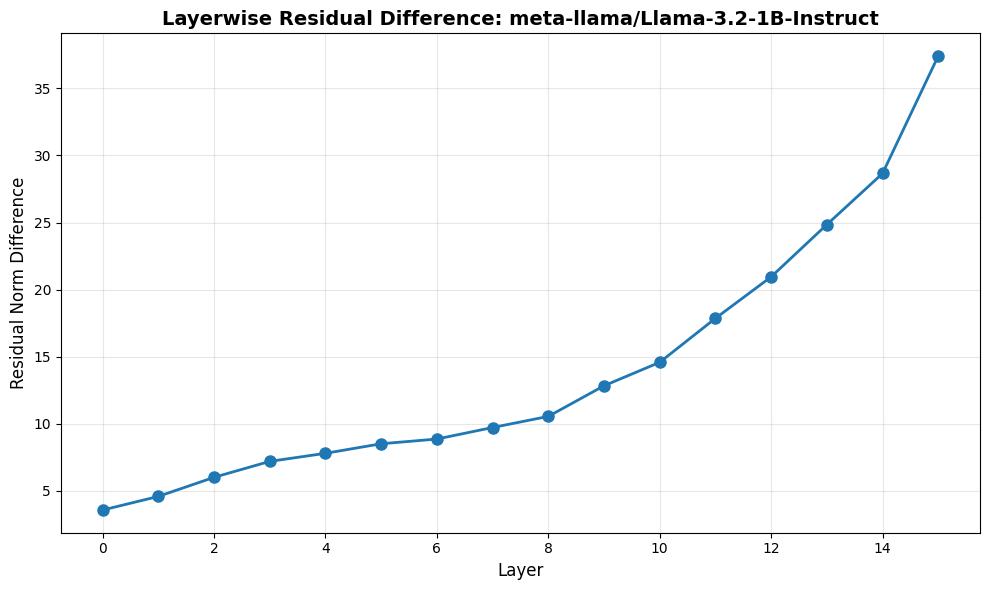

  Saved: ./results_layerwise/meta-llama_Llama-3.2-1B-Instruct/layerwise_residual_diff.png
Results saved to ./results_layerwise/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct

[2/3] Running Headwise Divergence...
Loading meta-llama/Llama-3.2-1B-Instruct...
Loaded pretrained model meta-llama/Llama-3.2-1B-Instruct into HookedTransformer
  Uncertainty tokens: 22 found

Experiment: Headwise Divergence
Model: meta-llama/Llama-3.2-1B-Instruct
Running model on real prompt...
Running model on fake prompt...
Computing headwise divergence...


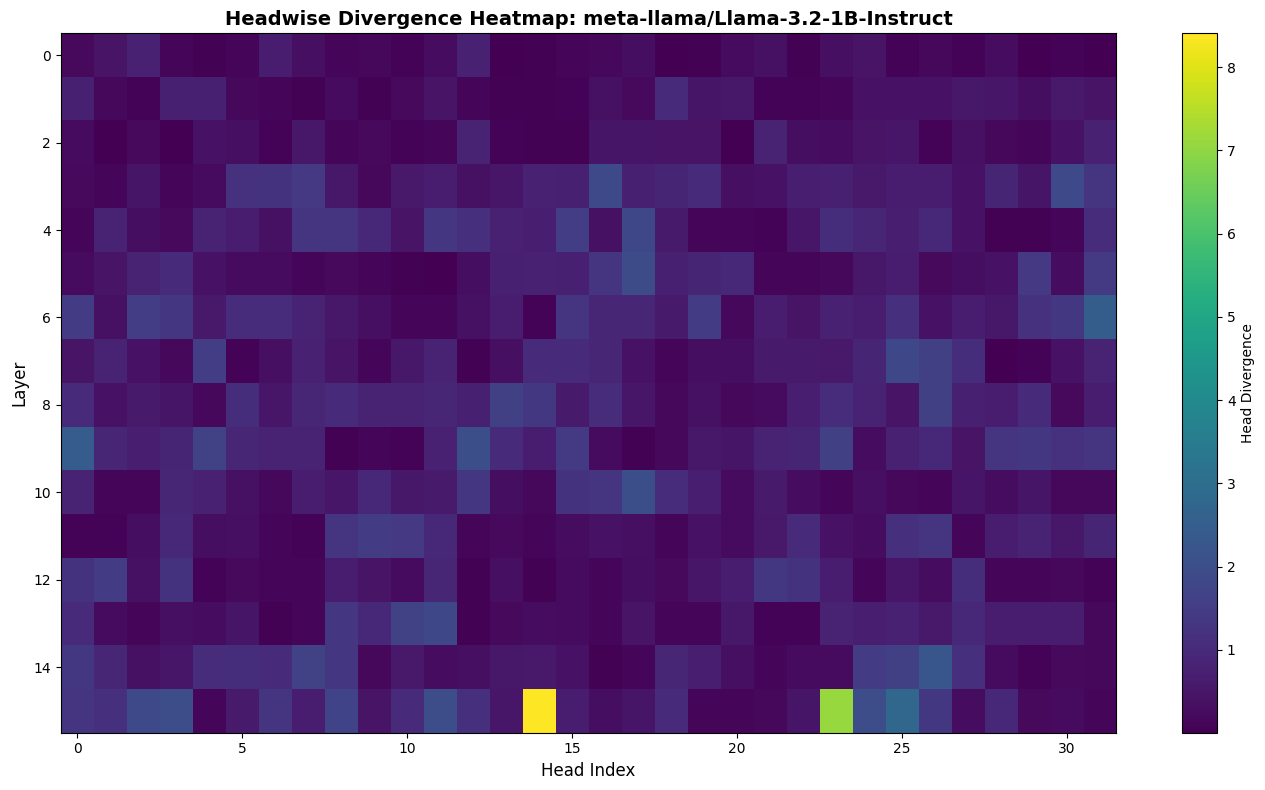

  Saved: ./results_headwise/meta-llama_Llama-3.2-1B-Instruct/headwise_divergence_heatmap.png

Top 15 Most Divergent Heads:
Rank   Head       Divergence     
-----------------------------------
1      L15H14       8.4062         
2      L15H23       7.1211         
3      L15H25       2.7695         
4      L6H31       2.4805         
5      L9H0        2.4375         
6      L14H26       2.2559         
7      L10H17       2.0117         
8      L9H12       2.0059         
9      L15H3        1.9980         
10     L15H24       1.9922         
11     L15H11       1.9766         
12     L5H17       1.9629         
13     L15H2        1.8613         
14     L3H16       1.8564         
15     L3H30       1.8447         
Results saved to ./results_headwise/meta-llama_Llama-3.2-1B-Instruct
Cleaned up meta-llama/Llama-3.2-1B-Instruct


All experiments completed for meta-llama/Llama-3.2-1B-Instruct!



In [22]:
MODEL_NAMES = ["meta-llama/Llama-3.2-1B-Instruct"]

prompt_real = "Who was the first US president?"
prompt_fake =  "Who was the first president of Kansantas?"

for model_name in MODEL_NAMES:
    try:
        print(f"\n\n{'#'*70}")
        print(f"# RUNNING ALL EXPERIMENTS FOR: {model_name}")
        print(f"{'#'*70}\n")

        # Experiment 1: Layerwise Residual Difference
        print("\n[1/3] Running Layerwise Residual Difference...")
        exp1 = LayerwiseResidualDifference(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_layerwise"
        )
        exp1.run()
        exp1.cleanup()

        # Experiment 2: Headwise Divergence
        print("\n[2/3] Running Headwise Divergence...")
        exp2 = HeadwiseDivergence(
            model_name,
            prompt_real,
            prompt_fake,
            results_dir="./results_headwise"
        )
        exp2.run()
        exp2.cleanup()

        print(f"\n\n{'='*70}")
        print(f"All experiments completed for {model_name}!")
        print(f"{'='*70}\n")

    except Exception as e:
        print(f"Error with {model_name}: {e}")
        import traceback
        traceback.print_exc()
        continue

1. Layerwise Residual Difference
 Uncertainty processing emerges late in the network. Early layers (0-8) treat both prompts similarly; late layers (10-15) diverge sharply. The model's uncertainty circuits activate in the final third.

2. Headwise Divergence Heatmap
Uncertainty is highly localized to just 2-3 specific heads. This is NOT distributed superposition—there's a concentrated circuit controlling the difference between real/fake responses.

3. Ablation Curve (Top 50 Heads)
Meaning: The top divergent heads are suppression heads??

Ablating them increases uncertainty (drops from 0.0008→0.0002 = lower uncertainty on output)
The effect plateaus after ~10 heads, confirming those are the core circuit